<p style="font-size: 20px;">
<b>Student Full Name:</b> Jasser Dhaouadi <br>
<b>Student ID:</b> U89818600 <br>
<b>Course:</b> Data Science Capstone - 1 <br>
<b>Semester:</b> Summer 2026 <br>
<b>Program:</b> OMDS <br>
<b>Boston University</b> 
</p>

# Week 1 - Linear Regression: Part 1 | Polynomial and Interaction Terms

# Homework - Working On My Datasets

### Packages

In [1]:
# Import libraries

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_score,
    recall_score,
    average_precision_score,
)

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Display settings
pd.set_option("display.max_columns", None)

## Dataset 1: CDC Diabetes Health Indicators  (sourced from BRFSS) 

### IMPORTANT NOTE:
- Because the target variable of our Diabetes Dataset contains three categories, this is a **multiclass classification problem, not a regression problem**.

- The three target classes are:
    - 0 = No diabetes
    - 1 = Prediabetes
    - 2 = Diabetes

- Therefore, **logistic regression** is used instead of **ordinary linear regression**. This keeps the Week 1 idea of modeling relationships between features and the outcome, but adapts it correctly for **classification**.

- This notebook applies the **Week 1 concepts** of **polynomial terms, interaction terms, overfitting, and multicollinearity** to the CDC Diabetes Health Indicators dataset.


#### [Dataset 1] | *1- Load the dataset & quick preview*

In [2]:
# Load the dataset
df = pd.read_csv("diabetes_012_health_indicators_BRFSS2015.csv")

print("Dataset shape:", df.shape)
display(df.head())
display(df.info())

Dataset shape: (253680, 22)


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  MentHlth   

None

- The dataset contains **253,680** observations and **22** columns. One column is the target variable, `Diabetes_012`, and the remaining 21 columns are **health, lifestyle, and demographic predictors**.

- The target variable is coded as:

    - 0 = No diabetes
    - 1 = Prediabetes
    - 2 = Diabetes

- Most variables are binary, ordinal, or integer-coded survey responses. This matters because **polynomial terms** should **NOT** be blindly applied to all variables. 
    - For binary variables, squaring the feature gives the same value, since 0² = 0 and 1² = 1. 
    - Therefore, polynomial terms are more meaningful for variables such as **BMI, Age, GenHlth, MentHlth, PhysHlth, Education, and Income**.

#### [Dataset 1] | *2- Basic data checks*

In [3]:
# Basic data checks

target = "Diabetes_012"

print("Missing values:")
display(df.isna().sum())

print("Duplicate rows:", df.duplicated().sum())

class_counts = df[target].value_counts().sort_index()
class_percent = (class_counts / len(df) * 100).round(2)

class_summary = pd.DataFrame({
    "Count": class_counts.astype(int),
    "Percent": class_percent
})

display(class_summary)

Missing values:


Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

Duplicate rows: 23899


,Count,Percent
Diabetes_012,,
0.0,213703,84.24
1.0,4631,1.83
2.0,35346,13.93


- There are **no missing** values in the dataset. 
- The dataset **does contain duplicate rows**, but that is expected because the features are mostly low-cardinality survey responses. 
    - Many people can share the same combination of answers, so duplicates should not automatically be removed.

- The class distribution is highly imbalanced:

    - Class 0, no diabetes, is the large majority.
    - Class 1, prediabetes, is very small.
    - Class 2, diabetes, is larger than prediabetes but still much smaller than the no-diabetes class.

- Because of this imbalance, accuracy alone is not enough. We should also use **balanced accuracy, macro F1, and class-specific precision/recall**.

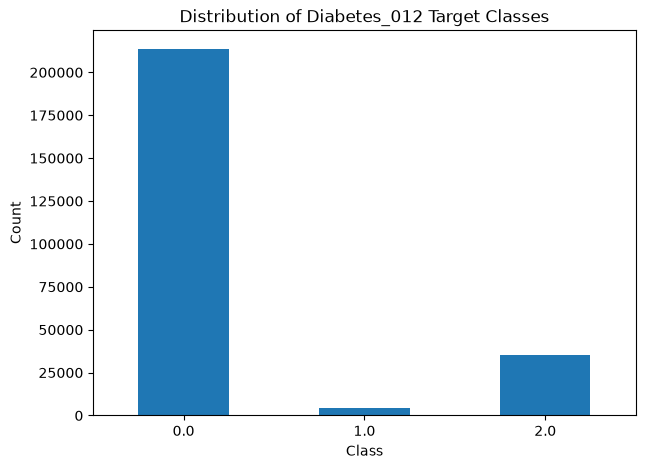

In [4]:
# Visualize target imbalance

plt.figure(figsize=(7, 5))
class_counts.plot(kind="bar")
plt.title("Distribution of Diabetes_012 Target Classes")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

- The target distribution shows a **strong imbalance**: 
    - Most records belong to class 0, meaning no diabetes. Prediabetes is especially rare.

- This imbalance affects **model interpretation**. 
    - A model can achieve high accuracy by mostly predicting the majority class, but that would not be useful for identifying diabetes or prediabetes. 
    - Therefore, the modeling cells use `class_weight="balanced"` and evaluate macro-level metrics.

#### [Dataset 1] | *3- Separate target and predictors*

In [5]:
y = df[target].astype(int)
X = df.drop(columns=[target])

# Identify feature groups

binary_cols = [
    col for col in X.columns
    if sorted(X[col].dropna().unique()) == [0.0, 1.0]
]

non_binary_cols = [col for col in X.columns if col not in binary_cols]

print("Binary columns:")
print(binary_cols)

print("\nNon-binary / ordinal / integer columns:")
print(non_binary_cols)

Binary columns:
['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex']

Non-binary / ordinal / integer columns:
['BMI', 'GenHlth', 'MentHlth', 'PhysHlth', 'Age', 'Education', 'Income']


- The **binary variables** are already coded as 0/1, so they do not need **one-hot encoding**.

- The **non-binary variables** include **BMI** and ordinal survey variables such as **GenHlth**, **MentHlth**, **PhysHlth**, **Age**, **Education**, and **Income**. 
    - These are the **best candidates** for **polynomial terms** because they can represent **nonlinear relationships**.
    - For example:
        - **BMI** may not have a purely **linear** relationship with diabetes risk. 
        - **Age** may also have a **nonlinear** relationship, where risk increases more strongly in later age groups.

#### [Dataset 1] | *4- Correlation check for original features*

In [6]:

corr = X.corr().abs()

upper = corr.where(
    np.triu(np.ones(corr.shape), k=1).astype(bool)
)

top_corr_pairs = (
    upper.stack()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_corr_pairs.columns = ["Feature 1", "Feature 2", "Absolute Correlation"]

display(top_corr_pairs)

,Feature 1,Feature 2,Absolute Correlation
0,GenHlth,PhysHlth,0.524364
1,PhysHlth,DiffWalk,0.478417
2,GenHlth,DiffWalk,0.456920
3,Education,Income,0.449106
4,GenHlth,Income,0.370014
5,MentHlth,PhysHlth,0.353619
6,HighBP,Age,0.344452
7,DiffWalk,Income,0.320124
8,GenHlth,MentHlth,0.301674
9,HighBP,GenHlth,0.300530


- This cell checks pairwise correlation before adding **polynomial or interaction terms**.

- The strongest correlations are expected among **related health-status variables** such as GenHlth, PhysHlth, DiffWalk, MentHlth, and Income. 

    - These relationships make sense because general health, physical health, difficulty walking, and income can be connected.

- **Correlation** is useful as a quick **multicollinearity** check, but it only measures **pairwise relationships**. It may miss cases where one feature is explained by a combination of several other features. That is why **VIF** is also useful.


#### [Dataset 1] | *5- VIF*

In [7]:
# VIF function

def compute_vif(data, sample_size=50000, random_state=42):
    """
    Compute Variance Inflation Factor for each feature.
    Uses a sample for speed when the dataset is large.
    """
    if len(data) > sample_size:
        data_for_vif = data.sample(sample_size, random_state=random_state)
    else:
        data_for_vif = data.copy()
    
    X_const = sm.add_constant(data_for_vif)
    
    vif_values = []
    
    for i, col in enumerate(X_const.columns):
        if col == "const":
            continue
        
        vif_values.append({
            "Feature": col,
            "VIF": variance_inflation_factor(X_const.values, i)
        })
    
    return (
        pd.DataFrame(vif_values)
        .sort_values("VIF", ascending=False)
        .reset_index(drop=True)
    )

vif_original = compute_vif(X)

display(vif_original.head(15))

,Feature,VIF
0,GenHlth,1.810659
1,PhysHlth,1.635505
2,DiffWalk,1.537131
3,Income,1.508400
4,Age,1.357699
5,HighBP,1.331182
6,Education,1.330455
7,MentHlth,1.249271
8,HighChol,1.179108
9,HeartDiseaseorAttack,1.171613


- The original feature set **does not show severe multicollinearity**. Most VIF values are **below** the common warning **threshold of 5**.

- This is important because the baseline model is **relatively stable**. 

- However, once we add polynomial and interaction terms, multicollinearity can increase because terms like Age and Age², or BMI and BMI², are mathematically related.

#### [Dataset 1] | *6- Train-test split*

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (202944, 21)
Testing shape: (50736, 21)


- A **stratified** train-test split is used so that the **class proportions are preserved** in both the training and testing sets.

- This is especially important because the prediabetes class is very small. Without **stratification**, the minority class could be underrepresented in either the training or test set.

#### [Dataset 1] | *7- Baseline multinomial logistic regression model*

In [9]:
baseline_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("logit", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        solver="lbfgs"
    ))
])

baseline_model.fit(X_train, y_train)

y_pred_base = baseline_model.predict(X_test)
y_prob_base = baseline_model.predict_proba(X_test)

baseline_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_base),
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred_base),
    "Macro F1": f1_score(y_test, y_pred_base, average="macro"),
    "Weighted F1": f1_score(y_test, y_pred_base, average="weighted"),
    "Macro OVR ROC AUC": roc_auc_score(
        y_test,
        y_prob_base,
        multi_class="ovr",
        average="macro"
    )
}

display(pd.DataFrame([baseline_metrics], index=["Baseline Logistic Regression"]))

print(classification_report(
    y_test,
    y_pred_base,
    target_names=["No Diabetes", "Prediabetes", "Diabetes"],
    digits=3
))

display(pd.DataFrame(
    confusion_matrix(y_test, y_pred_base),
    index=["Actual 0", "Actual 1", "Actual 2"],
    columns=["Predicted 0", "Predicted 1", "Predicted 2"]
))

,Accuracy,Balanced Accuracy,Macro F1,Weighted F1,Macro OVR ROC AUC
Baseline Logistic Regression,0.645754,0.524173,0.426883,0.72059,0.772785


              precision    recall  f1-score   support

 No Diabetes      0.951     0.663     0.781     42741
 Prediabetes      0.033     0.326     0.059       926
    Diabetes      0.353     0.583     0.440      7069

    accuracy                          0.646     50736
   macro avg      0.446     0.524     0.427     50736
weighted avg      0.851     0.646     0.721     50736



,Predicted 0,Predicted 1,Predicted 2
Actual 0,28337,7239,7165
Actual 1,240,302,384
Actual 2,1219,1726,4124


- The baseline model uses logistic regression because the target is **multiclass categorical**.

- Using the Diabetes dataset, the baseline model produced:

    - Accuracy: 0.646
    - Balanced accuracy: 0.524
    - Macro F1: 0.427
    - Macro OVR ROC AUC: 0.773

- Accuracy looks moderate, but **balanced accuracy** and **macro F1** show the harder truth: 
    - the model struggles with minority classes, especially prediabetes. 
    - This is expected because **class 1 is rare**.

- The confusion matrix helps show where the model is making mistakes. Many prediabetes cases are confused with no diabetes or diabetes.

#### [Dataset 1] | *8- Create polynomial and interaction terms*

In [10]:
# Create polynomial and interaction terms based on Week 1 concepts

def add_polynomial_interaction_terms(data):
    """
    Adds selected polynomial and interaction terms.
    
    Polynomial terms are added only for non-binary / ordinal variables.
    Interaction terms are chosen using domain logic.
    """
    out = data.copy()
    
    # Polynomial terms: avoid binary variables because x^2 = x for 0/1 features.
    polynomial_cols = [
        "BMI",
        "GenHlth",
        "MentHlth",
        "PhysHlth",
        "Age",
        "Education",
        "Income"
    ]
    
    for col in polynomial_cols:
        out[f"{col}_squared"] = out[col] ** 2
    
    # Interaction terms
    out["HighBP_x_HighChol"] = out["HighBP"] * out["HighChol"]
    out["BMI_x_PhysActivity"] = out["BMI"] * out["PhysActivity"]
    out["BMI_x_Age"] = out["BMI"] * out["Age"]
    out["GenHlth_x_PhysHlth"] = out["GenHlth"] * out["PhysHlth"]
    out["GenHlth_x_DiffWalk"] = out["GenHlth"] * out["DiffWalk"]
    out["Age_x_HighBP"] = out["Age"] * out["HighBP"]
    out["Age_x_HeartDiseaseorAttack"] = out["Age"] * out["HeartDiseaseorAttack"]
    
    return out

X_train_polynomial_interaction = add_polynomial_interaction_terms(X_train)
X_test_polynomial_interaction = add_polynomial_interaction_terms(X_test)

print("Original number of features:", X_train.shape[1])
print("Number of features after Week 1 terms:", X_train_polynomial_interaction.shape[1])

display(X_train_polynomial_interaction.head())

Original number of features: 21
Number of features after Week 1 terms: 35


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,BMI_squared,GenHlth_squared,MentHlth_squared,PhysHlth_squared,Age_squared,Education_squared,Income_squared,HighBP_x_HighChol,BMI_x_PhysActivity,BMI_x_Age,GenHlth_x_PhysHlth,GenHlth_x_DiffWalk,Age_x_HighBP,Age_x_HeartDiseaseorAttack
185494,1.0,0.0,1.0,25.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,1.0,10.0,4.0,4.0,625.0,4.0,0.0,0.0,100.0,16.0,16.0,0.0,25.0,250.0,0.0,0.0,10.0,0.0
217030,0.0,0.0,1.0,37.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,5.0,5.0,1369.0,1.0,0.0,0.0,1.0,25.0,25.0,0.0,37.0,37.0,0.0,0.0,0.0,0.0
641,1.0,1.0,1.0,35.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,5.0,3.0,1225.0,4.0,0.0,0.0,121.0,25.0,9.0,1.0,35.0,385.0,0.0,0.0,11.0,0.0
217863,0.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,2.0,0.0,5.0,0.0,1.0,3.0,4.0,6.0,729.0,4.0,0.0,25.0,9.0,16.0,36.0,0.0,27.0,81.0,10.0,0.0,0.0,0.0
53677,0.0,0.0,1.0,28.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,3.0,3.0,0.0,0.0,0.0,9.0,4.0,4.0,784.0,9.0,9.0,0.0,81.0,16.0,16.0,0.0,28.0,252.0,0.0,0.0,0.0,0.0


- This cell applies the Week 1 feature-engineering concepts.

- Polynomial terms are added for variables where nonlinear effects are plausible, such as **BMI**, **Age**, and **general health**.

- **Interaction terms** are added where the effect of one variable may depend on another variable. For example:

    - **HighBP × HighChol** tests whether having both conditions changes diabetes classification beyond their separate effects.
    - **BMI × Age** tests whether the BMI effect changes across age groups.
    - **GenHlth × PhysHlth** tests whether general health and physical health combine in a meaningful way.
    - **BMI × PhysActivity** tests whether the BMI relationship differs depending on physical activity.

- **NOTE**: This is a classification version of Week 1’s regression feature-engineering idea.

#### [Dataset 1] | *9- Check VIF after adding raw polynomial and interaction terms*

In [11]:
vif_polynomial_interaction_raw = compute_vif(X_train_polynomial_interaction)

display(vif_polynomial_interaction_raw.head(20))

,Feature,VIF
0,Education_squared,65.969165
1,Education,65.747975
2,Age,45.086537
3,GenHlth_squared,39.934154
4,BMI,32.048632
5,Income_squared,29.668779
6,GenHlth,29.550675
7,Income,29.225824
8,GenHlth_x_PhysHlth,29.097017
9,BMI_x_Age,27.206348


- After adding **raw polynomial and interaction terms**, **VIF values increase substantially**.

- This is expected because variables like **Age** and **Age²**, **BMI** and **BMI²**, or **Education** and **Education²** are mathematically related. 
    - This demonstrates the Week 1 warning that polynomial terms can introduce **multicollinearity**.

- High VIF does not always mean the model is useless, but it does mean individual coefficients may become unstable and harder to interpret. 
    - This is why **centering the variables** before creating polynomial and interaction terms can help.

#### [Dataset 1] | *10- Center variables before creating polynomial terms to reduce multicollinearity*

In [12]:
def add_centered_terms(data, centers=None):
    """
    Adds centered polynomial and interaction terms.
    Centering helps reduce multicollinearity between x and x^2.
    """
    out = data.copy()
    
    cols_to_center = [
        "BMI",
        "GenHlth",
        "MentHlth",
        "PhysHlth",
        "Age",
        "Education",
        "Income"
    ]
    
    if centers is None:
        centers = data[cols_to_center].mean()
    
    centered = data[cols_to_center] - centers
    
    # Centered polynomial terms
    for col in cols_to_center:
        out[f"{col}_centered_squared"] = centered[col] ** 2
    
    # Centered interaction terms where appropriate
    out["HighBP_x_HighChol"] = out["HighBP"] * out["HighChol"]
    out["BMI_centered_x_PhysActivity"] = centered["BMI"] * out["PhysActivity"]
    out["BMI_centered_x_Age_centered"] = centered["BMI"] * centered["Age"]
    out["GenHlth_centered_x_PhysHlth_centered"] = centered["GenHlth"] * centered["PhysHlth"]
    out["GenHlth_centered_x_DiffWalk"] = centered["GenHlth"] * out["DiffWalk"]
    out["Age_centered_x_HighBP"] = centered["Age"] * out["HighBP"]
    out["Age_centered_x_HeartDiseaseorAttack"] = centered["Age"] * out["HeartDiseaseorAttack"]
    
    return out, centers

X_train_centered, centers = add_centered_terms(X_train)
X_test_centered, _ = add_centered_terms(X_test, centers=centers)

vif_polynomial_interaction_centered = compute_vif(X_train_centered)

display(vif_polynomial_interaction_centered.head(20))

,Feature,VIF
0,PhysHlth_centered_squared,10.706630
1,PhysHlth,10.436955
2,MentHlth,9.040854
3,MentHlth_centered_squared,8.562621
4,GenHlth_centered_x_PhysHlth_centered,4.202406
5,BMI,4.117410
6,GenHlth_centered_x_DiffWalk,3.709405
7,HighBP_x_HighChol,3.559960
8,BMI_centered_x_PhysActivity,3.098313
9,Income,2.662490


- **Centering** reduces many of the **VIF problems** caused by raw polynomial terms.

- The reason is that a raw variable such as Age can be highly correlated with Age², especially when Age has a limited range. By subtracting the mean first, the squared term becomes less directly collinear with the original variable.

- Some VIF values may still be elevated because health variables are naturally related. 
    - For example, PhysHlth, MentHlth, GenHlth, and DiffWalk measure **overlapping aspects of health**.

#### [Dataset 1] | *11- Fit logistic regression with centered terms*

In [13]:
week1_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("logit", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        solver="lbfgs"
    ))
])

week1_model.fit(X_train_centered, y_train)

y_pred_week1 = week1_model.predict(X_test_centered)
y_prob_week1 = week1_model.predict_proba(X_test_centered)

week1_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_week1),
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred_week1),
    "Macro F1": f1_score(y_test, y_pred_week1, average="macro"),
    "Weighted F1": f1_score(y_test, y_pred_week1, average="weighted"),
    "Macro OVR ROC AUC": roc_auc_score(
        y_test,
        y_prob_week1,
        multi_class="ovr",
        average="macro"
    )
}

model_comparison = pd.DataFrame(
    [baseline_metrics, week1_metrics],
    index=[
        "Baseline Logistic Regression",
        "Logistic Regression with centered Terms"
    ]
)

display(model_comparison)

print(classification_report(
    y_test,
    y_pred_week1,
    target_names=["No Diabetes", "Prediabetes", "Diabetes"],
    digits=3
))

,Accuracy,Balanced Accuracy,Macro F1,Weighted F1,Macro OVR ROC AUC
Baseline Logistic Regression,0.645754,0.524173,0.426883,0.720590,0.772785
Logistic Regression with centered Terms,0.634126,0.524835,0.424587,0.712761,0.772737


              precision    recall  f1-score   support

 No Diabetes      0.954     0.647     0.771     42741
 Prediabetes      0.031     0.332     0.057       926
    Diabetes      0.357     0.596     0.446      7069

    accuracy                          0.634     50736
   macro avg      0.447     0.525     0.425     50736
weighted avg      0.854     0.634     0.713     50736



- The Week 1 engineered model adds **nonlinear and interaction information**, but in this dataset it performs very similarly to the baseline logistic regression.

- Using the uploaded dataset, the approximate comparison was:

| Model | Accuracy | Balanced Accuracy | Macro F1 | Macro OVR ROC AUC |
|---|---:|---:|---:|---:|
| Baseline Logistic Regression | 0.646 | 0.524 | 0.427 | 0.773 |
| Logistic Regression with Week 1 Terms | 0.634 | 0.524 | 0.424 | 0.773 |

- The engineered terms do not clearly improve predictive performance. 
    - This is an important result: adding polynomial and interaction terms does not automatically make a model better. It can add complexity, increase multicollinearity, and make interpretation harder.

- For this dataset, the main linear relationships already capture much of what the logistic regression model can learn.

#### [Dataset 1] | *12- Extract coefficients for interpretation*

In [14]:
feature_names = X_train_centered.columns
classes = week1_model.named_steps["logit"].classes_
coefs = week1_model.named_steps["logit"].coef_

coef_df = pd.DataFrame(
    coefs,
    index=[f"Class {c}" for c in classes],
    columns=feature_names
)

# Top predictors for diabetes class, class 2
top_positive_diabetes = (
    coef_df.loc["Class 2"]
    .sort_values(ascending=False)
    .head(12)
)

top_negative_diabetes = (
    coef_df.loc["Class 2"]
    .sort_values(ascending=True)
    .head(12)
)

print("Top positive coefficients for Class 2: Diabetes")
display(top_positive_diabetes)

print("Top negative coefficients for Class 2: Diabetes")
display(top_negative_diabetes)

Top positive coefficients for Class 2: Diabetes


GenHlth                        0.353145
BMI                            0.248676
Age                            0.223973
HighBP                         0.160183
CholCheck                      0.121104
HighChol                       0.074150
HeartDiseaseorAttack           0.071218
Sex                            0.069437
DiffWalk                       0.061499
MentHlth_centered_squared      0.051786
BMI_centered_x_Age_centered    0.035044
Stroke                         0.032316
Name: Class 2, dtype: float64

Top negative coefficients for Class 2: Diabetes


HvyAlcoholConsump                      -0.109928
Age_centered_squared                   -0.094380
BMI_centered_squared                   -0.086327
MentHlth                               -0.077174
GenHlth_centered_x_DiffWalk            -0.071518
Income                                 -0.067475
GenHlth_centered_x_PhysHlth_centered   -0.047066
Age_centered_x_HeartDiseaseorAttack    -0.025886
Age_centered_x_HighBP                  -0.024030
Income_centered_squared                -0.019195
PhysActivity                           -0.016471
GenHlth_centered_squared               -0.014411
Name: Class 2, dtype: float64

- The coefficient table gives an interpretable view of how the logistic regression model separates diabetes from the other classes.

    - For the diabetes class, the strongest positive coefficients are usually variables such as Age, GenHlth, BMI, HighBP, DiffWalk, and HeartDiseaseorAttack. 
    - This means higher values of these predictors are associated with higher log-odds of being classified as diabetes, holding the other model variables constant.

- However, because this is a multinomial logistic regression with standardized features and interaction terms, coefficients should be interpreted carefully. 
    - A positive coefficient does not mean direct causation. It means the feature helps distinguish that class from the others within this predictive model.

#### [Dataset 1] | *13- Summary*

- Overall, the Week 1 concepts were successfully applied to this classification dataset.

- The most important adjustment was using **logistic regression rather than ordinary linear regression** because the **target is categorical**. 

- **Polynomial and interaction terms** were added carefully, with attention to **multicollinearity and overfitting**.

- The final comparison showed that the engineered Week 1 terms **did not substantially** improve performance over the baseline model. 
    - This suggests that, for this diabetes dataset, model improvement may require other strategies such as class imbalance handling, alternative classifiers, threshold tuning, resampling methods, or more advanced feature selection.

## Dataset 2: Estimation of Obesity Levels

### IMPORTANT NOTE:
- This notebook applies the Week 1 concepts of **polynomial terms, interaction terms, multicollinearity, overfitting, and categorical feature** handling to the **obesity dataset**.

- The dataset is a **classification problem** because the target variable, `NObeyesdad`, contains obesity-level categories rather than a continuous numeric outcome. 
    - Therefore, **logistic regression** is used instead of **ordinary linear regression**.

#### [Dataset 2] | *1- Read the dataset*

In [15]:
DATA_PATH = "ObesityDataSet_raw_and_data_sinthetic.csv"

df_obesity = pd.read_csv(DATA_PATH)

print("Dataset shape:", df_obesity.shape)
display(df_obesity.head())
display(df_obesity.info())

Dataset shape: (2111, 17)


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF                             2111 non-null

None


- The dataset contains 2,111 rows and 17 columns. 
- The target column is **NObeyesdad**, which represents the **obesity** level. 
- The remaining columns describe 
    - **eating habits**
    - **physical condition**
    - **demographic information**
    - **lifestyle behaviors**

#### [Dataset 2] | *2- Basic data investigation*

In [16]:
target = "NObeyesdad"

print("Missing values by column:")
display(df_obesity.isna().sum())

print("Number of duplicated rows:", df_obesity.duplicated().sum())

class_counts = df_obesity[target].value_counts()
class_percent = (class_counts / len(df_obesity) * 100).round(2)

class_summary = pd.DataFrame({
    "Count": class_counts,
    "Percent": class_percent
})

display(class_summary)

Missing values by column:


Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

Number of duplicated rows: 24


,Count,Percent
NObeyesdad,,
Obesity_Type_I,351,16.63
Obesity_Type_III,324,15.35
Obesity_Type_II,297,14.07
Overweight_Level_I,290,13.74
Overweight_Level_II,290,13.74
Normal_Weight,287,13.60
Insufficient_Weight,272,12.88


- There are **no missing values** in the obesity levels dataset.

- The dataset has **some duplicated rows**. 
    - This is not automatically a problem because the dataset contains many categorical and rounded survey-style variables, so different individuals may share the same feature values.

- The target classes are **fairly balanced** compared with many real-world health datasets. 
    - This makes classification easier than highly imbalanced datasets, such as the diabetes dataset where prediabetes was very rare.

#### [Dataset 2] | *3- Identify numeric and categorical features*

In [17]:
X = df_obesity.drop(columns=[target])
y = df_obesity[target]

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

print("\nUnique values in categorical columns:")
for col in categorical_features:
    print(f"\n{col}:")
    print(df_obesity[col].value_counts())

Numeric features:
['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

Categorical features:
['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']

Unique values in categorical columns:

Gender:
Gender
Male      1068
Female    1043
Name: count, dtype: int64

family_history_with_overweight:
family_history_with_overweight
yes    1726
no      385
Name: count, dtype: int64

FAVC:
FAVC
yes    1866
no      245
Name: count, dtype: int64

CAEC:
CAEC
Sometimes     1765
Frequently     242
Always          53
no              51
Name: count, dtype: int64

SMOKE:
SMOKE
no     2067
yes      44
Name: count, dtype: int64

SCC:
SCC
no     2015
yes      96
Name: count, dtype: int64

CALC:
CALC
Sometimes     1401
no             639
Frequently      70
Always           1
Name: count, dtype: int64

MTRANS:
MTRANS
Public_Transportation    1580
Automobile                457
Walking                    56
Motorbike                  11
Bike                    

C:\Users\jdhao\AppData\Local\Temp\ipykernel_1456\3459009325.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns.tolist()


- The dataset contains both **numeric** and **categorical** predictors.

    - Numeric variables include 
        - `Age`
        - `Height`
        - `Weight`
        - `FCVC`
        - `NCP`
        - `CH2O`
        - `FAF`
        - `TUE`

    - Categorical variables include 
        - `Gender`
        - `family history`
        - `frequent high-calorie food consumption`
        - `eating between meals`
        - `smoking`
        - `calorie monitoring`
        - `alcohol consumption`
        - `transportation type`

- For modeling, the categorical variables need to be **one-hot encoded**. 

#### [Dataset 2] | *4- Target class distribution*

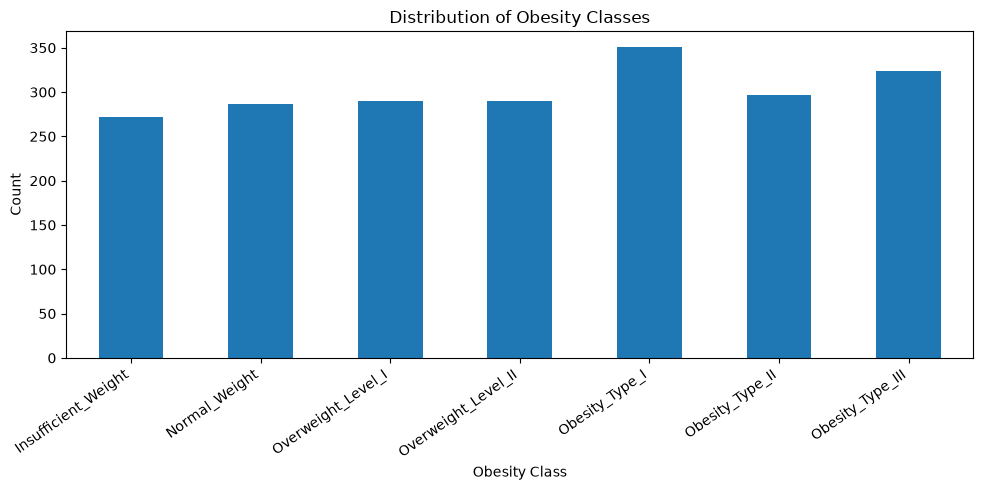

In [18]:
plt.figure(figsize=(10, 5))
class_counts.loc[
    [
        "Insufficient_Weight",
        "Normal_Weight",
        "Overweight_Level_I",
        "Overweight_Level_II",
        "Obesity_Type_I",
        "Obesity_Type_II",
        "Obesity_Type_III"
    ]
].plot(kind="bar")

plt.title("Distribution of Obesity Classes")
plt.xlabel("Obesity Class")
plt.ylabel("Count")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

- The target distribution is **relatively balanced** across the **seven obesity classes**.

- This is helpful because the **model has enough examples from each class to learn patterns**. 
    - Since the classes are not extremely imbalanced, accuracy is more meaningful here than it was in the diabetes dataset. 
    - However, **balanced accuracy** and **macro F1** are still useful because this is a **multiclass classification** problem.

#### [Dataset 2] | *5- Weight and height relationship by class*

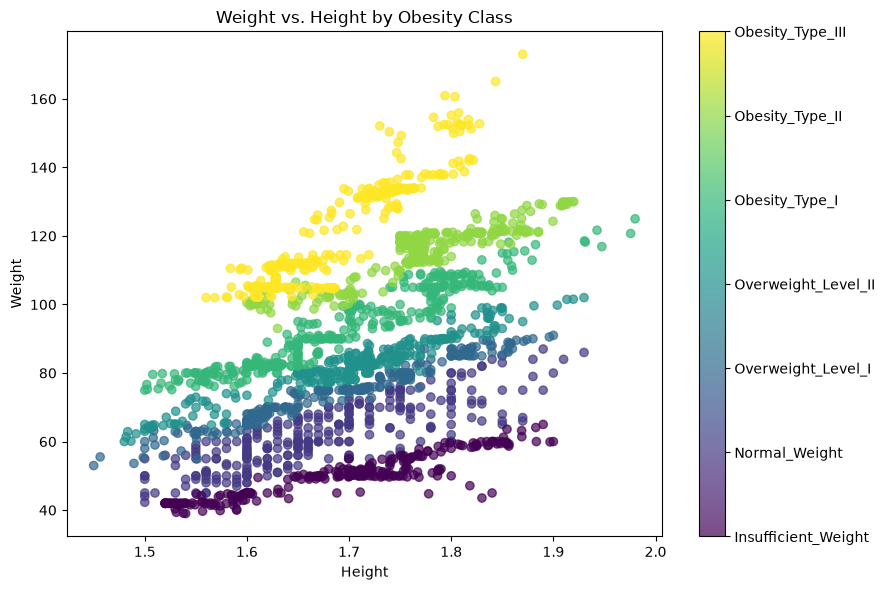

In [19]:
class_order = [
    "Insufficient_Weight",
    "Normal_Weight",
    "Overweight_Level_I",
    "Overweight_Level_II",
    "Obesity_Type_I",
    "Obesity_Type_II",
    "Obesity_Type_III"
]

class_codes = pd.Categorical(df_obesity[target], categories=class_order, ordered=True).codes

plt.figure(figsize=(9, 6))
scatter = plt.scatter(
    df_obesity["Height"],
    df_obesity["Weight"],
    c=class_codes,
    alpha=0.7
)

plt.title("Weight vs. Height by Obesity Class")
plt.xlabel("Height")
plt.ylabel("Weight")

cbar = plt.colorbar(scatter)
cbar.set_ticks(range(len(class_order)))
cbar.set_ticklabels(class_order)

plt.tight_layout()
plt.show()

- The scatterplot shows that **obesity classes** are strongly related to **the combination of height and weight**.

-  The meaning of weight depends partly on height. This supports creating an **interaction term** such as `Weight × Height` or other nonlinear body-size terms.

#### [Dataset 2] | *6- Train-test split and baseline preprocessing*

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

try:
    one_hot_encoder = OneHotEncoder(
        drop="first",
        handle_unknown="ignore",
        sparse_output=False
    )
except TypeError:
    one_hot_encoder = OneHotEncoder(
        drop="first",
        handle_unknown="ignore",
        sparse=False
    )

baseline_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", one_hot_encoder, categorical_features)
    ]
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (1688, 16)
Testing shape: (423, 16)


- A **stratified train-test split** is used so that each obesity class keeps approximately the **same proportion** in the **training** and **testing** sets.

- The numeric variables are **standardized** because logistic regression is **sensitive to scale**, especially when **polynomial** and **interaction terms** are later added.

- The categorical variables are **one-hot encoded**. The parameter `drop="first"` is used to avoid unnecessary dummy-variable **multicollinearity**.

#### [Dataset 2] | *7- Baseline logistic regression model*

In [21]:
baseline_model = Pipeline(
    steps=[
        ("preprocess", baseline_preprocessor),
        ("logit", LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            solver="lbfgs"
        ))
    ]
)

baseline_model.fit(X_train, y_train)

y_pred_base = baseline_model.predict(X_test)
y_prob_base = baseline_model.predict_proba(X_test)

baseline_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_base),
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred_base),
    "Macro F1": f1_score(y_test, y_pred_base, average="macro"),
    "Weighted F1": f1_score(y_test, y_pred_base, average="weighted"),
    "Macro OVR ROC AUC": roc_auc_score(
        y_test,
        y_prob_base,
        multi_class="ovr",
        average="macro",
        labels=baseline_model.named_steps["logit"].classes_
    )
}

display(pd.DataFrame([baseline_metrics], index=["Baseline Logistic Regression"]))

print(classification_report(
    y_test,
    y_pred_base,
    labels=class_order,
    digits=3
))

,Accuracy,Balanced Accuracy,Macro F1,Weighted F1,Macro OVR ROC AUC
Baseline Logistic Regression,0.874704,0.873688,0.872019,0.873961,0.984401


                     precision    recall  f1-score   support

Insufficient_Weight      0.931     1.000     0.964        54
      Normal_Weight      0.830     0.759     0.793        58
 Overweight_Level_I      0.717     0.741     0.729        58
Overweight_Level_II      0.807     0.793     0.800        58
     Obesity_Type_I      0.910     0.871     0.891        70
    Obesity_Type_II      0.906     0.967     0.935        60
   Obesity_Type_III      1.000     0.985     0.992        65

           accuracy                          0.875       423
          macro avg      0.872     0.874     0.872       423
       weighted avg      0.874     0.875     0.874       423



- The baseline logistic regression model performs well because the **obesity classes are strongly related to features** such as *weight*, *height*, *eating habits*, and *physical condition*.

- Using the uploaded obesity dataset, the baseline model produced approximately:

    - Accuracy: 0.875
    - Balanced Accuracy: 0.874
    - Macro F1: 0.872
    - Macro OVR ROC AUC: 0.984

- This gives us a strong baseline before adding Week 1 polynomial and interaction terms.

#### [Dataset 2] | *8- Correlation check for numeric features*

In [22]:
numeric_corr = X_train[numeric_features].corr().abs()

upper_corr = numeric_corr.where(
    np.triu(np.ones(numeric_corr.shape), k=1).astype(bool)
)

top_numeric_corr = (
    upper_corr.stack()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)

top_numeric_corr.columns = ["Feature 1", "Feature 2", "Absolute Correlation"]

display(top_numeric_corr)

,Feature 1,Feature 2,Absolute Correlation
0,Height,Weight,0.456985
1,Height,FAF,0.300220
2,Age,TUE,0.276573
3,Height,NCP,0.247687
4,Height,CH2O,0.218752
5,Weight,FCVC,0.203266
6,Age,Weight,0.199537
7,Weight,CH2O,0.198834
8,CH2O,FAF,0.176415
9,Age,FAF,0.148418


- Correlation is a useful first check for **multicollinearity**: 
    - If two variables are highly correlated, their coefficients may become harder to interpret.
    - However, correlation only checks two variables at a time. 
    - **VIF** is stronger because it can detect whether one feature is explained by a combination of multiple other features.

#### [Dataset 2] | *9- VIF for original numeric features*

In [23]:
def compute_vif(data):
    """
    Compute VIF for numeric features.
    Constant columns are removed before calculation.
    """
    vif_data = data.copy()
    
    # Remove constant columns, if any
    vif_data = vif_data.loc[:, vif_data.nunique() > 1]
    
    X_const = sm.add_constant(vif_data, has_constant="add")
    
    results = []
    
    for i, col in enumerate(X_const.columns):
        if col == "const":
            continue
        
        results.append({
            "Feature": col,
            "VIF": variance_inflation_factor(X_const.values, i)
        })
    
    return (
        pd.DataFrame(results)
        .sort_values("VIF", ascending=False)
        .reset_index(drop=True)
    )

vif_original_numeric = compute_vif(X_train[numeric_features])

display(vif_original_numeric)

,Feature,VIF
0,Height,1.609431
1,Weight,1.537816
2,FAF,1.208373
3,Age,1.156788
4,FCVC,1.099081
5,TUE,1.098095
6,CH2O,1.093597
7,NCP,1.075728


- The original **numeric features** generally have** low VIF values**

- This means the numeric predictors are **not severely multicollinear** before adding polynomial and interaction terms. That is a good starting point.

- The main Week 1 warning is that polynomial terms such as `Weight²` or `Age²` can create **multicollinearity** with their original variables. The next cells test that directly.

#### [Dataset 2] | *10- Add raw polynomial and interaction terms*

In [24]:
def add_polynomial_interaction_raw_terms(data):
    """
    Add raw polynomial and interaction terms based on Week 1 concepts.
    These are intentionally raw terms so we can inspect multicollinearity.
    """
    out = data.copy()
    
    # Polynomial terms for numeric variables
    for col in numeric_features:
        out[f"{col}_squared"] = out[col] ** 2
    
    # Interaction terms based on domain logic
    out["Weight_x_Height"] = out["Weight"] * out["Height"]
    out["Age_x_Weight"] = out["Age"] * out["Weight"]
    out["FAF_x_TUE"] = out["FAF"] * out["TUE"]
    out["CH2O_x_FAF"] = out["CH2O"] * out["FAF"]
    
    # Interactions between numeric and binary/categorical behavior variables
    out["FCVC_x_FAVC_yes"] = out["FCVC"] * (out["FAVC"] == "yes").astype(int)
    
    out["family_history_x_FAVC"] = (
        (out["family_history_with_overweight"] == "yes").astype(int)
        * (out["FAVC"] == "yes").astype(int)
    )
    
    out["NCP_x_CAEC_Sometimes"] = (
        out["NCP"] * (out["CAEC"] == "Sometimes").astype(int)
    )
    
    return out

X_train_raw_polynomial_interaction = add_polynomial_interaction_raw_terms(X_train)

raw_numeric_cols = X_train_raw_polynomial_interaction.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

vif_raw_polynomial_interaction = compute_vif(X_train_raw_polynomial_interaction[raw_numeric_cols])

display(vif_raw_polynomial_interaction.head(20))

,Feature,VIF
0,Height_squared,1669.589190
1,Height,1428.571591
2,Weight_x_Height,1317.187240
3,Weight,840.145928
4,Weight_squared,92.823077
5,FCVC_squared,77.192674
6,FCVC,75.553225
7,Age,75.015179
8,Age_x_Weight,58.023666
9,CH2O_squared,42.603673


- **Raw polynomial and interaction terms** cause a **large increase in VIF**.

- Variables such as `Height` and `Height²`, or `Weight` and `Weight²`, are mathematically related. 

- Interaction terms such as `Weight × Height` can also become strongly related to the original variables.

- This does not mean the model cannot predict well, but it does mean the individual coefficients may become unstable and harder to interpret.

#### [Dataset 2] | *11- Add centered polynomial and interaction terms*

In [25]:
def add_centered_terms(data, centers=None):
    """
    Add centered polynomial and interaction terms.
    Centering reduces multicollinearity between x and x^2.
    """
    out = data.copy()
    
    if centers is None:
        centers = data[numeric_features].mean()
    
    centered = data[numeric_features] - centers
    
    # Centered polynomial terms
    for col in numeric_features:
        out[f"{col}_centered_squared"] = centered[col] ** 2
    
    # Centered interaction terms
    out["Weight_centered_x_Height_centered"] = (
        centered["Weight"] * centered["Height"]
    )
    
    out["Age_centered_x_Weight_centered"] = (
        centered["Age"] * centered["Weight"]
    )
    
    out["FAF_centered_x_TUE_centered"] = (
        centered["FAF"] * centered["TUE"]
    )
    
    out["CH2O_centered_x_FAF_centered"] = (
        centered["CH2O"] * centered["FAF"]
    )
    
    # Numeric x categorical/binary interactions
    out["FCVC_centered_x_FAVC_yes"] = (
        centered["FCVC"] * (out["FAVC"] == "yes").astype(int)
    )
    
    out["family_history_x_FAVC"] = (
        (out["family_history_with_overweight"] == "yes").astype(int)
        * (out["FAVC"] == "yes").astype(int)
    )
    
    out["NCP_centered_x_CAEC_Sometimes"] = (
        centered["NCP"] * (out["CAEC"] == "Sometimes").astype(int)
    )
    
    return out, centers

X_train_, train_centers = add_centered_terms(X_train)
X_test_, _ = add_centered_terms(X_test, centers=train_centers)

numeric_cols = X_train_.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

vif_centered_ = compute_vif(X_train_[numeric_cols])

display(vif_centered_.head(20))

,Feature,VIF
0,FCVC_centered_x_FAVC_yes,9.871333
1,FCVC,9.486409
2,NCP,5.401146
3,NCP_centered_x_CAEC_Sometimes,4.162622
4,Weight_centered_x_Height_centered,3.251798
5,Age,2.901048
6,Weight,2.693090
7,NCP_centered_squared,2.514735
8,Weight_centered_squared,2.399600
9,Age_centered_squared,2.364510


- **Centering** the numeric variables before creating polynomial and interaction terms **reduces the VIF values substantially**.

- This happens because the squared terms are no longer as strongly aligned with the original variables. 
    - For example, `Weight` and centered `Weight²` are usually less collinear than `Weight` and raw `Weight²`.

- This is a practical way to apply Week 1 polynomial terms while reducing coefficient instability.

#### [Dataset 2] | *12- Fit logistic regression with Week 1 engineered terms*

In [26]:
week1_numeric_features = X_train_.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

week1_categorical_features = X_train_.select_dtypes(
    include=["object"]
).columns.tolist()

try:
    week1_one_hot_encoder = OneHotEncoder(
        drop="first",
        handle_unknown="ignore",
        sparse_output=False
    )
except TypeError:
    week1_one_hot_encoder = OneHotEncoder(
        drop="first",
        handle_unknown="ignore",
        sparse=False
    )

week1_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), week1_numeric_features),
        ("cat", week1_one_hot_encoder, week1_categorical_features)
    ]
)

week1_model = Pipeline(
    steps=[
        ("preprocess", week1_preprocessor),
        ("logit", LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            solver="lbfgs"
        ))
    ]
)

week1_model.fit(X_train_, y_train)

y_pred_week1 = week1_model.predict(X_test_)
y_prob_week1 = week1_model.predict_proba(X_test_)

week1_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_week1),
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred_week1),
    "Macro F1": f1_score(y_test, y_pred_week1, average="macro"),
    "Weighted F1": f1_score(y_test, y_pred_week1, average="weighted"),
    "Macro OVR ROC AUC": roc_auc_score(
        y_test,
        y_prob_week1,
        multi_class="ovr",
        average="macro",
        labels=week1_model.named_steps["logit"].classes_
    )
}

model_comparison = pd.DataFrame(
    [baseline_metrics, week1_metrics],
    index=[
        "Baseline Logistic Regression",
        "Logistic Regression with Week 1 Terms"
    ]
)

display(model_comparison)

C:\Users\jdhao\AppData\Local\Temp\ipykernel_1456\3012196408.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  week1_categorical_features = X_train_.select_dtypes(


,Accuracy,Balanced Accuracy,Macro F1,Weighted F1,Macro OVR ROC AUC
Baseline Logistic Regression,0.874704,0.873688,0.872019,0.873961,0.984401
Logistic Regression with Week 1 Terms,0.914894,0.913185,0.913215,0.914962,0.991817


- The Week 1 engineered logistic regression model **improves performance** over the baseline.

- Using the obesity levels dataset, the approximate comparison was:

| Model | Accuracy | Balanced Accuracy | Macro F1 | Macro OVR ROC AUC |
|---|---:|---:|---:|---:|
| Baseline Logistic Regression | 0.875 | 0.874 | 0.872 | 0.984 |
| Logistic Regression with Week 1 Terms | 0.915 | 0.913 | 0.913 | 0.992 |

- This suggests that polynomial and interaction terms are useful for this dataset. 
    - That makes sense because obesity level depends on nonlinear body-size relationships and interactions between lifestyle, eating habits, and physical condition.

#### [Dataset 2] | *13- Overfitting check: train vs test performance*

In [27]:
def evaluate_model(model, X_data, y_data):
    y_pred = model.predict(X_data)
    
    return {
        "Accuracy": accuracy_score(y_data, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_data, y_pred),
        "Macro F1": f1_score(y_data, y_pred, average="macro")
    }

overfitting_check = pd.DataFrame([
    {
        "Model": "Baseline",
        "Split": "Train",
        **evaluate_model(baseline_model, X_train, y_train)
    },
    {
        "Model": "Baseline",
        "Split": "Test",
        **evaluate_model(baseline_model, X_test, y_test)
    },
    {
        "Model": "Week 1 Engineered",
        "Split": "Train",
        **evaluate_model(week1_model, X_train_, y_train)
    },
    {
        "Model": "Week 1 Engineered",
        "Split": "Test",
        **evaluate_model(week1_model, X_test_, y_test)
    }
])

display(overfitting_check)

,Model,Split,Accuracy,Balanced Accuracy,Macro F1
0,Baseline,Train,0.905213,0.904189,0.902490
1,Baseline,Test,0.874704,0.873688,0.872019
2,Week 1 Engineered,Train,0.949052,0.948496,0.948102
3,Week 1 Engineered,Test,0.914894,0.913185,0.913215



- The Week 1 engineered model has **higher training performance** than the baseline, which is **expected** because it has **more features**. 
- However, the **test performance also improves**, meaning the **extra polynomial and interaction terms are not just memorizing the training data**.
- There is still a train-test gap, so we should be careful not to keep adding many more polynomial terms. 
- Week 1 warns that too many polynomial terms can create an overly complex model that fits the training data but generalizes poorly.

#### [Dataset 2] | *14- Classification report and confusion matrix*

In [28]:
print("Classification Report: Week 1 Engineered Model - Obesity Levels Dataset")
print(classification_report(
    y_test,
    y_pred_week1,
    labels=class_order,
    digits=3
))

conf_matrix = pd.DataFrame(
    confusion_matrix(y_test, y_pred_week1, labels=class_order),
    index=[f"Actual {label}" for label in class_order],
    columns=[f"Predicted {label}" for label in class_order]
)

display(conf_matrix)

Classification Report: Week 1 Engineered Model - Obesity Levels Dataset
                     precision    recall  f1-score   support

Insufficient_Weight      0.929     0.963     0.945        54
      Normal_Weight      0.828     0.828     0.828        58
 Overweight_Level_I      0.817     0.845     0.831        58
Overweight_Level_II      0.907     0.845     0.875        58
     Obesity_Type_I      0.917     0.943     0.930        70
    Obesity_Type_II      1.000     1.000     1.000        60
   Obesity_Type_III      1.000     0.969     0.984        65

           accuracy                          0.915       423
          macro avg      0.914     0.913     0.913       423
       weighted avg      0.916     0.915     0.915       423



,Predicted Insufficient_Weight,Predicted Normal_Weight,Predicted Overweight_Level_I,Predicted Overweight_Level_II,Predicted Obesity_Type_I,Predicted Obesity_Type_II,Predicted Obesity_Type_III
Actual Insufficient_Weight,52,2,0,0,0,0,0
Actual Normal_Weight,2,48,8,0,0,0,0
Actual Overweight_Level_I,0,7,49,2,0,0,0
Actual Overweight_Level_II,0,1,2,49,6,0,0
Actual Obesity_Type_I,0,0,1,3,66,0,0
Actual Obesity_Type_II,0,0,0,0,0,60,0
Actual Obesity_Type_III,2,0,0,0,0,0,63


- The classification report shows **strong performance** across most obesity classes.

- The model performs especially well for the more extreme obesity categories, such as `Obesity_Type_II` and `Obesity_Type_III`. 
    - This makes sense because those classes are more clearly separated by weight, height, and related nonlinear body-size terms.

- Most remaining errors occur between neighboring categories, such as :
    - normal weight vs. overweight 
    - overweight level I vs. overweight level II. 
- These are naturally harder to separate because adjacent categories are closer to each other.

#### [Dataset 2] | *15- Model comparison*

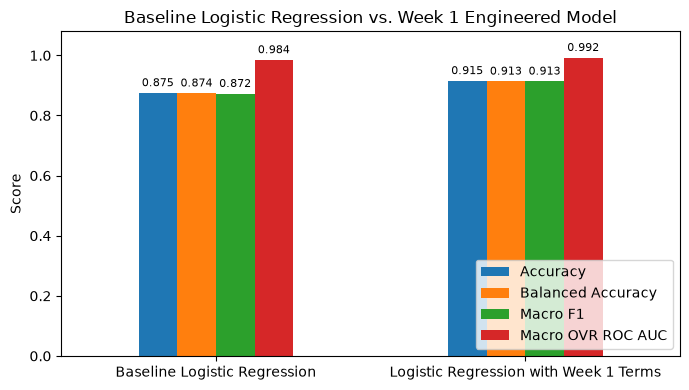

In [44]:
ax = model_comparison[
    ["Accuracy", "Balanced Accuracy", "Macro F1", "Macro OVR ROC AUC"]
].plot(
    kind="bar",
    figsize=(7, 4)
)

# Add bar values
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=3,
        fontsize=8
    )

plt.title("Baseline Logistic Regression vs. Week 1 Engineered Model")
plt.ylabel("Score")
plt.xticks(rotation=0, ha="center")
plt.ylim(0, 1.08)  # slightly above 1 to make space for labels
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

- The model comparison plot confirms that the Week 1 engineered model performs better than the baseline model.

- The improvement is visible across accuracy, balanced accuracy, macro F1, and ROC AUC. This **supports the use of selected polynomial and interaction terms for this obesity classification problem**.

- The model improved because the added terms were based on reasonable domain logic, not because every possible polynomial and interaction term was added.

#### [Dataset 2] | *16- Interpret coefficients for one obesity class*

In [18]:
# Extract feature names after preprocessing
feature_names = week1_model.named_steps["preprocess"].get_feature_names_out()

coef_df = pd.DataFrame(
    week1_model.named_steps["logit"].coef_,
    index=week1_model.named_steps["logit"].classes_,
    columns=feature_names
)

obesity_class = "Obesity_Type_III"

top_positive = (
    coef_df.loc[obesity_class]
    .sort_values(ascending=False)
    .head(12)
)

top_negative = (
    coef_df.loc[obesity_class]
    .sort_values(ascending=True)
    .head(12)
)

print(f"Top positive coefficients for {obesity_class}:")
display(top_positive)

print(f"Top negative coefficients for {obesity_class}:")
display(top_negative)

Top positive coefficients for Obesity_Type_III:


num__Weight_centered_squared          3.226098
num__Weight                           3.136528
num__FCVC                             0.974434
num__FCVC_centered_x_FAVC_yes         0.971791
cat__MTRANS_Public_Transportation     0.646492
num__FCVC_centered_squared            0.637139
cat__CALC_Sometimes                   0.585976
num__NCP_centered_x_CAEC_Sometimes    0.406402
num__FAF_centered_squared             0.401337
num__family_history_x_FAVC            0.351138
num__NCP                              0.306357
num__FAF_centered_x_TUE_centered      0.227173
Name: Obesity_Type_III, dtype: float64

Top negative coefficients for Obesity_Type_III:


cat__Gender_Male                         -1.729661
num__Weight_centered_x_Height_centered   -1.687728
num__Height                              -1.308132
num__TUE_centered_squared                -0.945419
num__FAF                                 -0.908052
num__Age_centered_squared                -0.847123
num__Age_centered_x_Weight_centered      -0.478176
num__Height_centered_squared             -0.474176
cat__CALC_no                             -0.399661
num__NCP_centered_squared                -0.365691
cat__CALC_Frequently                     -0.175458
cat__CAEC_Frequently                     -0.065102
Name: Obesity_Type_III, dtype: float64

- This cell examines which variables most strongly help the model identify `Obesity_Type_III`.
    - **Positive coefficients** increase the log-odds of the selected class relative to the other classes. 
    - **Negative coefficients** decrease the log-odds.

- For `Obesity_Type_III`, **weight-related terms** are expected to be among the strongest predictors. 
- Some **interaction terms** may also appear because the effect of one variable can depend on another. 
    - For example, the meaning of weight changes depending on height, which is why interaction terms are useful here.



#### [Dataset 2] | *17- Summary*

- Overall, the Week 1 concepts were successfully applied to the obesity dataset.

- Because this is a **classification** problem, **logistic regression** was the correct model choice. 

- Polynomial terms helped capture nonlinear relationships, especially around body-size variables. Interaction terms helped capture cases where the effect of one variable depends on another.

- The **Week 1 engineered model** improved test performance compared with the baseline model, while the **VIF analysis** showed why **centering** is important before creating **polynomial terms**.

## Dataset 3: Cervical Cancer Risk Factors

### IMPORTANT NOTE:


- The Week 1 concepts include **polynomial terms, interaction terms, multicollinearity, VIF, correlation checks, and overfitting checks**. 

- Because the **outcome is categorical**, this notebook uses **logistic regression instead of ordinary linear regression**.

#### [Dataset 3] | *1- Load and clean the dataset*

In [19]:
DATA_PATH = "risk_factors_cervical_cancer.csv"

df_cervical = pd.read_csv(DATA_PATH)

# The dataset uses "?" to represent missing values.
df_cervical = df_cervical.replace("?", np.nan)

# Convert all columns to numeric because this dataset stores many numeric values as objects.
for col in df_cervical.columns:
    df_cervical[col] = pd.to_numeric(df_cervical[col], errors="coerce")

print("Dataset shape:", df_cervical.shape)
display(df_cervical.head())
display(df_cervical.info())

Dataset shape: (858, 36)


,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,IUD (years),STDs,STDs (number),STDs:condylomatosis,STDs:cervical condylomatosis,STDs:vaginal condylomatosis,STDs:vulvo-perineal condylomatosis,STDs:syphilis,STDs:pelvic inflammatory disease,STDs:genital herpes,STDs:molluscum contagiosum,STDs:AIDS,STDs:HIV,STDs:Hepatitis B,STDs:HPV,STDs: Number of diagnosis,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,0,0,0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,0,0,0,0,0,0,0,0
2,34,1.0,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,0,0,0,0,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,1,0,1,0,0,0,0,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,0,0,0,0,0,0,0,0


<class 'pandas.DataFrame'>
RangeIndex: 858 entries, 0 to 857
Data columns (total 36 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 858 non-null    int64  
 1   Number of sexual partners           832 non-null    float64
 2   First sexual intercourse            851 non-null    float64
 3   Num of pregnancies                  802 non-null    float64
 4   Smokes                              845 non-null    float64
 5   Smokes (years)                      845 non-null    float64
 6   Smokes (packs/year)                 845 non-null    float64
 7   Hormonal Contraceptives             750 non-null    float64
 8   Hormonal Contraceptives (years)     750 non-null    float64
 9   IUD                                 741 non-null    float64
 10  IUD (years)                         741 non-null    float64
 11  STDs                                753 non-null    floa

None

- The dataset has **858 rows** and **36 columns**. 

- The raw file contains several missing values represented as question marks, so those values were converted to `NaN`.

- After conversion, the columns are numeric. 

    - This is useful because the dataset **does not require one-hot encoding** in the same way as the obesity dataset. 
    
    - Most variables are already continuous, binary, or integer-coded medical-risk variables.

#### [Dataset 3] | *2- Basic data investigation*

In [20]:
target = "Biopsy"

diagnostic_targets = ["Hinselmann", "Schiller", "Citology", "Biopsy"]

missing_summary = (
    df_cervical.isna()
    .sum()
    .sort_values(ascending=False)
)

target_counts = df_cervical[target].value_counts().sort_index()
target_percent = (target_counts / len(df_cervical) * 100).round(2)

target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percent": target_percent
})

print("Top columns with missing values:")
display(missing_summary[missing_summary > 0].head(15))

print("Target distribution:")
display(target_summary)

print("Diagnostic target totals:")
display(df_cervical[diagnostic_targets].sum())

Top columns with missing values:


STDs: Time since first diagnosis      787
STDs: Time since last diagnosis       787
IUD                                   117
IUD (years)                           117
Hormonal Contraceptives               108
Hormonal Contraceptives (years)       108
STDs:HPV                              105
STDs:AIDS                             105
STDs:Hepatitis B                      105
STDs:HIV                              105
STDs                                  105
STDs:cervical condylomatosis          105
STDs:vulvo-perineal condylomatosis    105
STDs:syphilis                         105
STDs:pelvic inflammatory disease      105
dtype: int64

Target distribution:


,Count,Percent
Biopsy,,
0,803,93.59
1,55,6.41


Diagnostic target totals:


Hinselmann    35
Schiller      74
Citology      44
Biopsy        55
dtype: int64

- The dataset contains **several missing values**, especially in the **STD diagnosis timing variables**. 
    - This matches the dataset description that **some patients did not answer** all questions.

- The target variable `Biopsy` is highly **imbalanced**. 
    - Most patients have `Biopsy = 0`
    - while only a small percentage have `Biopsy = 1`.

- Because of this imbalance, accuracy alone is not enough. The model should also be evaluated using **balanced accuracy**, **recall**, **F1-score**, **ROC AUC**, and **average precision**.

#### [Dataset 3] | *3- Define predictors and avoid target leakage*

In [21]:
# Predict Biopsy using only risk-factor variables.
# The other diagnostic targets are removed to avoid target leakage.
X = df_cervical.drop(columns=diagnostic_targets)
y = df_cervical[target].astype(int)

print("Predictor shape:", X.shape)
print("Target shape:", y.shape)

display(X.head())

Predictor shape: (858, 32)
Target shape: (858,)


,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,IUD (years),STDs,STDs (number),STDs:condylomatosis,STDs:cervical condylomatosis,STDs:vaginal condylomatosis,STDs:vulvo-perineal condylomatosis,STDs:syphilis,STDs:pelvic inflammatory disease,STDs:genital herpes,STDs:molluscum contagiosum,STDs:AIDS,STDs:HIV,STDs:Hepatitis B,STDs:HPV,STDs: Number of diagnosis,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,0,0,0,0
2,34,1.0,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,1,0,1,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,0,0,0,0


- The model predicts `Biopsy` using the risk-factor variables only.

- The columns `Hinselmann`, `Schiller`, and `Citology` are removed because they are also **diagnostic target variables**. Including them would make the model look better, but it would not be a **clean risk-factor model**.

#### [Dataset 3] | *4- Target distribution*

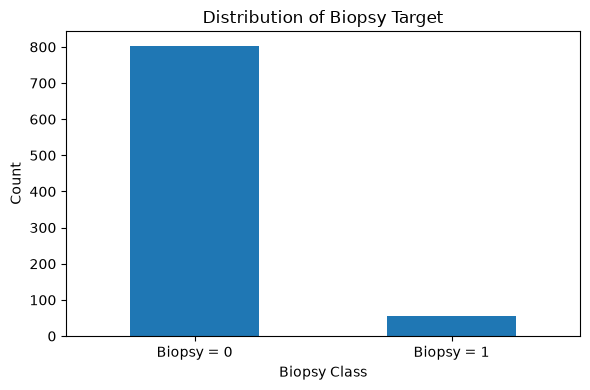

In [22]:
plt.figure(figsize=(6, 4))

target_counts.rename(
    index={0: "Biopsy = 0", 1: "Biopsy = 1"}
).plot(kind="bar")

plt.title("Distribution of Biopsy Target")
plt.xlabel("Biopsy Class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

- The target distribution shows a **strong class imbalance**.

- This is important because a model can achieve high accuracy by mostly predicting the majority class. 
    - For this reason, evaluation must focus on **minority-class detection**, not just total accuracy.

#### [Dataset 3] | *5- Missing values*

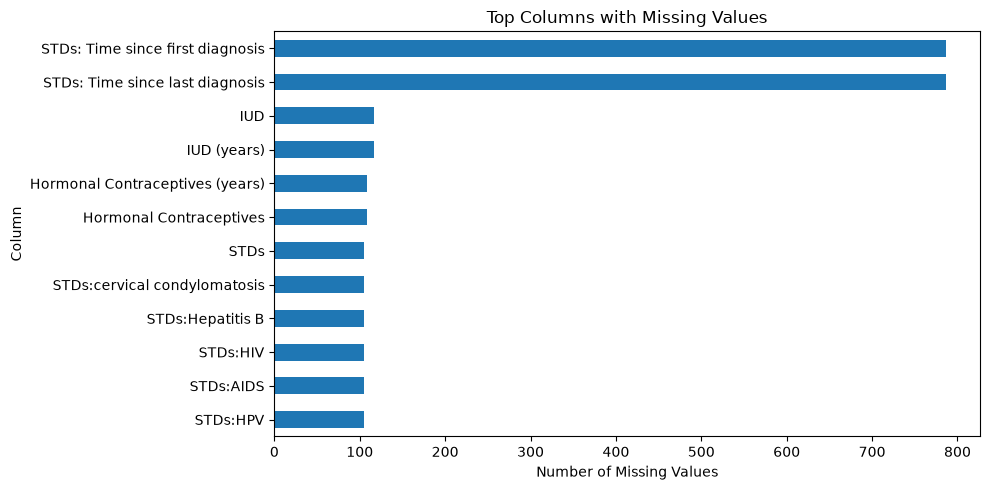

In [23]:
plt.figure(figsize=(10, 5))

missing_summary[missing_summary > 0].head(12).sort_values().plot(kind="barh")

plt.title("Top Columns with Missing Values")
plt.xlabel("Number of Missing Values")
plt.ylabel("Column")
plt.tight_layout()
plt.show()

- The missing-value plot shows that **missingness is concentrated in a few medical-history variables**, especially **STD timing variables**.

- Instead of dropping these columns, we use **median imputation and missingness indicators**. 

    - This keeps the information from the original variables while also allowing the model to learn whether missingness itself is informative.

#### [Dataset 3] | *6- Train-test split and imputation*

In [25]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

imputer = SimpleImputer(strategy="median", add_indicator=True)

X_train_imputed_array = imputer.fit_transform(X_train_raw)
X_test_imputed_array = imputer.transform(X_test_raw)

original_feature_names = X_train_raw.columns.tolist()

try:
    imputed_feature_names = imputer.get_feature_names_out(original_feature_names)
except AttributeError:
    missing_indicator_names = [
        f"missingindicator_{original_feature_names[i]}"
        for i in imputer.indicator_.features_
    ]
    imputed_feature_names = original_feature_names + missing_indicator_names

X_train_imputed = pd.DataFrame(
    X_train_imputed_array,
    columns=imputed_feature_names,
    index=X_train_raw.index
)

X_test_imputed = pd.DataFrame(
    X_test_imputed_array,
    columns=imputed_feature_names,
    index=X_test_raw.index
)

print("Training shape after imputation:", X_train_imputed.shape)
print("Testing shape after imputation:", X_test_imputed.shape)

Training shape after imputation: (686, 58)
Testing shape after imputation: (172, 58)


- A **stratified** train-test split is used so that the **rare positive** biopsy cases are **represented in both training and testing sets**.

- **Median imputation** handles missing values. 

- **Missingness indicators** are also added, which is useful because in medical survey data, not answering a question may itself carry information.

#### [Dataset 3] | *7- Baseline logistic regression*

In [28]:
baseline_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("logit", LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            solver="liblinear",
            random_state=42
        ))
    ]
)

baseline_model.fit(X_train_imputed, y_train)

y_pred_base = baseline_model.predict(X_test_imputed)
y_prob_base = baseline_model.predict_proba(X_test_imputed)[:, 1]

baseline_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_base),
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred_base),
    "Precision": precision_score(y_test, y_pred_base, zero_division=0),
    "Recall": recall_score(y_test, y_pred_base, zero_division=0),
    "F1": f1_score(y_test, y_pred_base, zero_division=0),
    "ROC AUC": roc_auc_score(y_test, y_prob_base),
    "Average Precision": average_precision_score(y_test, y_prob_base)
}

display(pd.DataFrame([baseline_metrics], index=["Baseline Logistic Regression"]))

print(classification_report(y_test, y_pred_base, digits=3, zero_division=0))

display(pd.DataFrame(
    confusion_matrix(y_test, y_pred_base),
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
))

,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC AUC,Average Precision
Baseline Logistic Regression,0.744186,0.482213,0.054054,0.181818,0.083333,0.513834,0.072385


              precision    recall  f1-score   support

           0      0.933     0.783     0.851       161
           1      0.054     0.182     0.083        11

    accuracy                          0.744       172
   macro avg      0.494     0.482     0.467       172
weighted avg      0.877     0.744     0.802       172



,Predicted 0,Predicted 1
Actual 0,126,35
Actual 1,9,2


- The baseline model uses l**ogistic regression** because the **target is binary classification**.

- The argument `class_weight="balanced"` is used because the **positive biopsy class is rare**. 

    - This tells the model to **give more importance to minority-class errors**.

- The confusion matrix is especially important here. 
    - In a medical-risk dataset, **missing positive cases can be more concerning than overall accuracy**.

#### [Dataset 3] | *8- Correlation check*

In [29]:
original_imputed_features = X_train_imputed[original_feature_names]

corr_matrix = original_imputed_features.corr().abs()

upper_corr = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

top_corr_pairs = (
    upper_corr.stack()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)

top_corr_pairs.columns = ["Feature 1", "Feature 2", "Absolute Correlation"]

display(top_corr_pairs)

,Feature 1,Feature 2,Absolute Correlation
0,STDs:condylomatosis,STDs:vulvo-perineal condylomatosis,0.983979
1,STDs: Time since first diagnosis,STDs: Time since last diagnosis,0.928551
2,STDs,STDs (number),0.917844
3,STDs,STDs: Number of diagnosis,0.909387
4,STDs (number),STDs: Number of diagnosis,0.908737
5,STDs (number),STDs:condylomatosis,0.887843
6,Dx:Cancer,Dx:HPV,0.879363
7,STDs (number),STDs:vulvo-perineal condylomatosis,0.876061
8,IUD,IUD (years),0.756403
9,Smokes (years),Smokes (packs/year),0.723532


- This cell checks pairwise **correlation before adding polynomial or interaction terms**.

- **Correlation** is a useful first check for **multicollinearity**. 
    - However, it only checks two variables at a time. 
    - Some multicollinearity can come from a combination of variables, so **VIF** is also needed.

#### [Dataset 3] | *9- VIF*

In [30]:
def compute_vif(data):
    """
    Compute Variance Inflation Factor for each feature.
    Constant columns are removed before calculation.
    """
    vif_data = data.copy()
    vif_data = vif_data.loc[:, vif_data.nunique() > 1]
    
    X_const = sm.add_constant(vif_data, has_constant="add")
    
    results = []
    
    for i, col in enumerate(X_const.columns):
        if col == "const":
            continue
        
        try:
            vif_value = variance_inflation_factor(X_const.values, i)
        except Exception:
            vif_value = np.nan
        
        results.append({
            "Feature": col,
            "VIF": vif_value
        })
    
    return (
        pd.DataFrame(results)
        .sort_values("VIF", ascending=False)
        .reset_index(drop=True)
    )

vif_original = compute_vif(original_imputed_features)

display(vif_original.head(20))

d:\BU\Summer 2026\DX799 O1 Data Science Capstone\HWs\MOD-C-1\.venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Feature,VIF
0,STDs (number),inf
1,STDs:syphilis,inf
2,STDs:vulvo-perineal condylomatosis,inf
3,STDs:vaginal condylomatosis,inf
4,STDs:HPV,inf
5,STDs:Hepatitis B,inf
6,STDs:HIV,inf
7,STDs:molluscum contagiosum,inf
8,STDs:pelvic inflammatory disease,inf
9,STDs:condylomatosis,inf


- The **VIF** table checks whether each feature can be explained by the **other features**.

- Some STD-related variables may show very high or infinite VIF values because several STD columns are **structurally related**. 
    - For example, `STDs (number)` is connected to the individual STD indicator columns.

- This is a useful Week 1 point: **multicollinearity does not only happen because of polynomial terms**. **It can also happen when a dataset contains summary variables and component variables together**.

#### [Dataset 3] | *10- Add raw polynomial and interaction terms*

In [31]:
continuous_cols = [
    "Age",
    "Number of sexual partners",
    "First sexual intercourse",
    "Num of pregnancies",
    "Smokes (years)",
    "Smokes (packs/year)",
    "Hormonal Contraceptives (years)",
    "IUD (years)",
    "STDs (number)",
    "STDs: Number of diagnosis",
    "STDs: Time since first diagnosis",
    "STDs: Time since last diagnosis"
]

continuous_cols = [col for col in continuous_cols if col in X_train_imputed.columns]

def add_raw_week1_terms(data):
    """
    Add raw polynomial and interaction terms.
    These are intentionally raw so we can inspect multicollinearity.
    """
    out = data.copy()
    
    # Polynomial terms
    for col in continuous_cols:
        out[f"{col}_squared"] = out[col] ** 2
    
    # Interaction terms based on domain logic
    out["Age_x_NumPregnancies"] = out["Age"] * out["Num of pregnancies"]
    out["Age_x_FirstSexualIntercourse"] = out["Age"] * out["First sexual intercourse"]
    out["SexualPartners_x_STDsNumber"] = (
        out["Number of sexual partners"] * out["STDs (number)"]
    )
    out["SmokesYears_x_PacksPerYear"] = (
        out["Smokes (years)"] * out["Smokes (packs/year)"]
    )
    out["HormonalYears_x_IUDYears"] = (
        out["Hormonal Contraceptives (years)"] * out["IUD (years)"]
    )
    out["STDs_x_STDsNumber"] = out["STDs"] * out["STDs (number)"]
    out["DxCancer_x_DxHPV"] = out["Dx:Cancer"] * out["Dx:HPV"]
    out["HormonalContraceptives_x_HormonalYears"] = (
        out["Hormonal Contraceptives"] * out["Hormonal Contraceptives (years)"]
    )
    
    return out

X_train_raw_week1 = add_raw_week1_terms(X_train_imputed)

raw_week1_term_cols = [
    col for col in X_train_raw_week1.columns
    if (
        col in original_feature_names
        or "_squared" in col
        or "_x_" in col
        or "SexualPartners" in col
        or "SmokesYears" in col
        or "HormonalYears" in col
        or "DxCancer" in col
    )
]

vif_raw_week1 = compute_vif(X_train_raw_week1[raw_week1_term_cols])

display(vif_raw_week1.head(25))

d:\BU\Summer 2026\DX799 O1 Data Science Capstone\HWs\MOD-C-1\.venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Feature,VIF
0,Hormonal Contraceptives (years),inf
1,STDs:condylomatosis,inf
2,STDs:vaginal condylomatosis,inf
3,STDs:syphilis,inf
4,STDs:vulvo-perineal condylomatosis,inf
5,STDs,inf
6,STDs (number),inf
7,STDs: Number of diagnosis_squared,inf
8,STDs (number)_squared,inf
9,STDs: Time since last diagnosis,inf


- **Polynomial terms** are added only for **continuous or count-like variables**. 

- **Binary variables** are not squared because for binary variables, **0² = 0 and 1² = 1**, so the squared term would duplicate the original feature.

- The raw VIF values are expected to increase. 

    - This happens because variables such as `Age` and `Age²`, or `Smokes (years)` and `Smokes (years)²`, are mathematically related.

#### [Dataset 3] | *11- Center variables before creating interaction terms*

In [32]:
def add_centered_week1_terms(data, centers=None):
    """
    Add centered polynomial and interaction terms.
    Centering helps reduce multicollinearity between x and x^2.
    """
    out = data.copy()
    
    if centers is None:
        centers = data[continuous_cols].mean()
    
    centered = data[continuous_cols] - centers
    
    # Centered polynomial terms
    for col in continuous_cols:
        out[f"{col}_centered_squared"] = centered[col] ** 2
    
    # Centered interaction terms
    out["Age_centered_x_NumPregnancies_centered"] = (
        centered["Age"] * centered["Num of pregnancies"]
    )
    
    out["Age_centered_x_FirstSexualIntercourse_centered"] = (
        centered["Age"] * centered["First sexual intercourse"]
    )
    
    out["SexualPartners_centered_x_STDsNumber_centered"] = (
        centered["Number of sexual partners"] * centered["STDs (number)"]
    )
    
    out["SmokesYears_centered_x_PacksPerYear_centered"] = (
        centered["Smokes (years)"] * centered["Smokes (packs/year)"]
    )
    
    out["HormonalYears_centered_x_IUDYears_centered"] = (
        centered["Hormonal Contraceptives (years)"] * centered["IUD (years)"]
    )
    
    # Binary by continuous interactions
    out["STDs_x_STDsNumber_centered"] = (
        out["STDs"] * centered["STDs (number)"]
    )
    
    out["HormonalContraceptives_x_HormonalYears_centered"] = (
        out["Hormonal Contraceptives"]
        * centered["Hormonal Contraceptives (years)"]
    )
    
    # Binary by binary interaction
    out["DxCancer_x_DxHPV"] = out["Dx:Cancer"] * out["Dx:HPV"]
    
    return out, centers

X_train_week1, train_centers = add_centered_week1_terms(X_train_imputed)
X_test_week1, _ = add_centered_week1_terms(X_test_imputed, centers=train_centers)

# Drop constant columns if any exist in the training data.
constant_cols = X_train_week1.columns[X_train_week1.nunique() <= 1].tolist()

X_train_week1 = X_train_week1.drop(columns=constant_cols)
X_test_week1 = X_test_week1.drop(columns=constant_cols)

print("Number of constant columns removed:", len(constant_cols))
print("Training shape after Week 1 terms:", X_train_week1.shape)
print("Testing shape after Week 1 terms:", X_test_week1.shape)

Number of constant columns removed: 3
Training shape after Week 1 terms: (686, 75)
Testing shape after Week 1 terms: (172, 75)


- **Centering continuous variables before creating squared and interaction terms**.

- **Centering** reduces the correlation between a variable and its squared version. 

    - This makes the model coefficients more stable and easier to interpret.

- **Constant columns are removed** because they do not help the model and can create problems in VIF or coefficient interpretation.

#### [Dataset 3] | *12- VIF after centering*

In [33]:
centered_week1_vif_cols = [
    col for col in X_train_week1.columns
    if (
        col in original_feature_names
        or "centered_squared" in col
        or "_centered_x_" in col
        or "DxCancer" in col
    )
]

vif_centered_week1 = compute_vif(X_train_week1[centered_week1_vif_cols])

display(vif_centered_week1.head(25))

d:\BU\Summer 2026\DX799 O1 Data Science Capstone\HWs\MOD-C-1\.venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Feature,VIF
0,STDs (number),inf
1,STDs:condylomatosis,inf
2,STDs:vaginal condylomatosis,inf
3,STDs,inf
4,STDs: Number of diagnosis_centered_squared,inf
5,STDs: Time since last diagnosis,inf
6,STDs: Time since first diagnosis,inf
7,STDs: Number of diagnosis,inf
8,STDs:HPV,inf
9,STDs:Hepatitis B,inf


- The **centered terms** should **reduce** some of the **multicollinearity** created by **raw polynomial terms**.

- However, some **high VIF values may remain** because the cervical cancer dataset has structurally **related variables**. 

    - For example, **STD summary columns and individual STD columns** can be mathematically or clinically related.

- This is an important interpretation: **centering helps with polynomial multicollinearity, but it does not remove all structural multicollinearity already present in the dataset**.

#### [Dataset 3] | *13- Logistic regression with centered polynomials and interaction terms*

In [34]:
week1_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("logit", LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            solver="liblinear",
            random_state=42
        ))
    ]
)

week1_model.fit(X_train_week1, y_train)

y_pred_week1 = week1_model.predict(X_test_week1)
y_prob_week1 = week1_model.predict_proba(X_test_week1)[:, 1]

week1_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_week1),
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred_week1),
    "Precision": precision_score(y_test, y_pred_week1, zero_division=0),
    "Recall": recall_score(y_test, y_pred_week1, zero_division=0),
    "F1": f1_score(y_test, y_pred_week1, zero_division=0),
    "ROC AUC": roc_auc_score(y_test, y_prob_week1),
    "Average Precision": average_precision_score(y_test, y_prob_week1)
}

model_comparison = pd.DataFrame(
    [baseline_metrics, week1_metrics],
    index=[
        "Baseline Logistic Regression",
        "Logistic Regression with Week 1 Terms"
    ]
)

display(model_comparison)

print(classification_report(y_test, y_pred_week1, digits=3, zero_division=0))

display(pd.DataFrame(
    confusion_matrix(y_test, y_pred_week1),
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
))

,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC AUC,Average Precision
Baseline Logistic Regression,0.744186,0.482213,0.054054,0.181818,0.083333,0.513834,0.072385
Logistic Regression with Week 1 Terms,0.750000,0.400621,0.000000,0.000000,0.000000,0.439864,0.058448


              precision    recall  f1-score   support

           0      0.921     0.801     0.857       161
           1      0.000     0.000     0.000        11

    accuracy                          0.750       172
   macro avg      0.461     0.401     0.429       172
weighted avg      0.862     0.750     0.802       172



,Predicted 0,Predicted 1
Actual 0,129,32
Actual 1,11,0


- This model applies **polynomial and interaction terms in a classification setting**.

- The main question is whether the added terms improve minority-class detection and overall generalization.
    -  Because the positive biopsy class is small, the results can vary noticeably depending on the train-test split.

- If the Week 1 model improves recall, F1, ROC AUC, or average precision, that suggests the nonlinear and interaction terms are useful. 

- If performance does not improve (THIS IS WHAT WE GOT), that suggests the added complexity may be creating **instability** rather than useful signal.

#### [Dataset 3] | *14- Overfitting check*

In [35]:
def evaluate_binary_model(model, X_data, y_data):
    y_pred = model.predict(X_data)
    y_prob = model.predict_proba(X_data)[:, 1]
    
    return {
        "Accuracy": accuracy_score(y_data, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_data, y_pred),
        "Precision": precision_score(y_data, y_pred, zero_division=0),
        "Recall": recall_score(y_data, y_pred, zero_division=0),
        "F1": f1_score(y_data, y_pred, zero_division=0),
        "ROC AUC": roc_auc_score(y_data, y_prob),
        "Average Precision": average_precision_score(y_data, y_prob)
    }

overfitting_check = pd.DataFrame([
    {
        "Model": "Baseline",
        "Split": "Train",
        **evaluate_binary_model(baseline_model, X_train_imputed, y_train)
    },
    {
        "Model": "Baseline",
        "Split": "Test",
        **evaluate_binary_model(baseline_model, X_test_imputed, y_test)
    },
    {
        "Model": "Week 1 Engineered",
        "Split": "Train",
        **evaluate_binary_model(week1_model, X_train_week1, y_train)
    },
    {
        "Model": "Week 1 Engineered",
        "Split": "Test",
        **evaluate_binary_model(week1_model, X_test_week1, y_test)
    }
])

display(overfitting_check)

,Model,Split,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC AUC,Average Precision
0,Baseline,Train,0.811953,0.751345,0.206897,0.681818,0.317460,0.835033,0.285036
1,Baseline,Test,0.744186,0.482213,0.054054,0.181818,0.083333,0.513834,0.072385
2,Week 1 Engineered,Train,0.819242,0.797579,0.229730,0.772727,0.354167,0.879319,0.349376
3,Week 1 Engineered,Test,0.750000,0.400621,0.000000,0.000000,0.000000,0.439864,0.058448


- If the Week 1 engineered model performs much better on training data than testing data, that suggests overfitting. 

- For this dataset, **overfitting is a serious concern** because the dataset is **small** and the positive biopsy class is **rare**.

#### [Dataset 3] | *15- Model comparison*

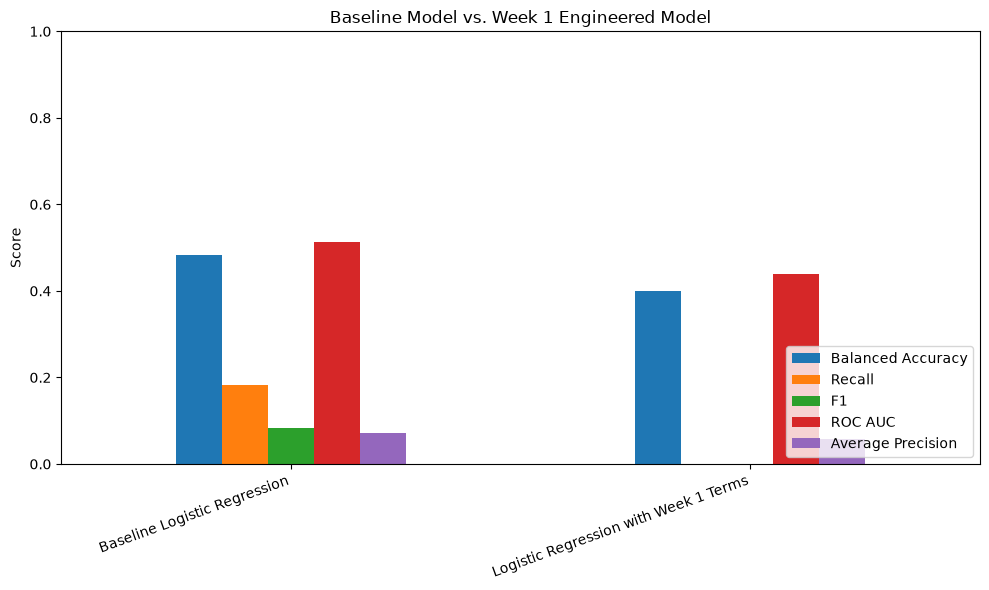

In [36]:
model_comparison[
    ["Balanced Accuracy", "Recall", "F1", "ROC AUC", "Average Precision"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Baseline Model vs. Week 1 Engineered Model")
plt.ylabel("Score")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

- This visual compares the **baseline logistic regression model with the Week 1 engineered model**.

- For this **imbalanced dataset**, balanced accuracy, recall, F1, ROC AUC, and average precision are more informative than accuracy alone.

- The goal is not just to increase total accuracy, but **to improve the model's ability to identify the rare positive biopsy cases**.

#### [Dataset 3] | *16- Summary*

Because this is a small and highly imbalanced classification dataset, adding polynomial and interaction terms must be done cautiously. 

The most important Week 1 lessons here are:

1. Use logistic regression instead of ordinary linear regression because the target is categorical.
2. Add polynomial and interaction terms only when they make domain sense.
3. Check multicollinearity using correlation and VIF.
4. Compare train and test performance to detect overfitting.
5. Avoid target leakage by excluding other diagnostic target variables from the predictors.